In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [71]:
mgl = pd.read_csv('transaksi_ritel_mgl.csv')
yk = pd.read_csv('transaksi_ritel_yk.csv')

In [72]:
mgl.head(10)

,tanggal,kode,nama,jumlah,harga,area
0,10-04-2020,Item-11,Sabun Cuci Piring,3.0,14000.0,MGL
1,10-04-2020,Item-11,Sabun Cuci Piring,3.0,14000.0,MGL
2,10-04-2020,Item-11,Sabun Cuci Piring,2.0,14000.0,MGL
3,10-04-2020,Item-03,Gula Pasir Putih 1 kg,2.0,12500.0,MGL
4,10-04-2020,Item-11,Sabun Cuci Piring,3.0,14000.0,MGL
5,10-04-2020,Item-11,Sabun Cuci Piring,4.0,14000.0,MGL
6,19-04-2020,Item-26,Susu Bubuk 195g,7.0,45000.0,MGL
7,11-04-2020,Item-11,Sabun Cuci Piring,2.0,14000.0,MGL
8,11-04-2020,Item-11,Sabun Cuci Piring,3.0,14000.0,MGL
9,11-04-2020,Item-16,Balsem Putih 20 gram,1.0,22300.0,MGL


In [73]:
yk.head(10)

,tanggal,kode,nama,jumlah,harga,area
0,10-04-2020,Item-11,Sabun Cuci Piring,3.0,14000.0,YK
1,10-04-2020,Item-11,Sabun Cuci Piring,3.0,14000.0,YK
2,10-04-2020,Item-11,Sabun Cuci Piring,2.0,14000.0,YK
3,10-04-2020,Item-03,Gula Pasir Putih 1 kg,2.0,12500.0,YK
4,10-04-2020,Item-11,Sabun Cuci Piring,3.0,14000.0,YK
5,10-04-2020,Item-11,Sabun Cuci Piring,4.0,14000.0,YK
6,19-04-2020,Item-26,Susu Bubuk 195g,7.0,45000.0,YK
7,11-04-2020,Item-11,Sabun Cuci Piring,2.0,14000.0,YK
8,11-04-2020,Item-11,Sabun Cuci Piring,3.0,14000.0,YK
9,11-04-2020,Item-16,Balsem Putih 20 gram,1.0,22300.0,YK


In [74]:
mgl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3845 entries, 0 to 3844
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tanggal  3829 non-null   object 
 1   kode     3830 non-null   object 
 2   nama     3830 non-null   object 
 3   jumlah   3830 non-null   float64
 4   harga    3831 non-null   float64
 5   area     3845 non-null   object 
dtypes: float64(2), object(4)
memory usage: 180.4+ KB


In [75]:
yk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20004 entries, 0 to 20003
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tanggal  19980 non-null  object 
 1   kode     19982 non-null  object 
 2   nama     19911 non-null  object 
 3   jumlah   19912 non-null  float64
 4   harga    19912 non-null  float64
 5   area     20004 non-null  object 
dtypes: float64(2), object(4)
memory usage: 937.8+ KB


In [76]:
mgl.describe()

,jumlah,harga
count,3830.000000,3831.000000
mean,4.397911,14445.549465
std,4.531587,13232.133544
min,1.000000,1000.000000
25%,2.000000,5000.000000
50%,3.000000,12000.000000
75%,4.000000,16000.000000
max,20.000000,63000.000000


In [77]:
yk.describe()

,jumlah,harga
count,19912.000000,19912.000000
mean,6.215448,13102.490960
std,5.606753,11856.964564
min,1.000000,1000.000000
25%,2.000000,7000.000000
50%,4.000000,12000.000000
75%,10.000000,15000.000000
max,20.000000,63000.000000


In [78]:
print('Jumlah data MGL :', mgl.shape)
print('Jumlah data YK  :', yk.shape)

Jumlah data MGL : (3845, 6)
Jumlah data YK  : (20004, 6)


In [79]:
# Menggabungkan dataset
merged_df = pd.concat([mgl, yk], ignore_index=True)

# Menampilkan jumlah data
print('Jumlah seluruh baris data :', merged_df.shape[0])
print('Jumlah seluruh kolom data :', merged_df.shape[1])

Jumlah seluruh baris data : 23849
Jumlah seluruh kolom data : 6


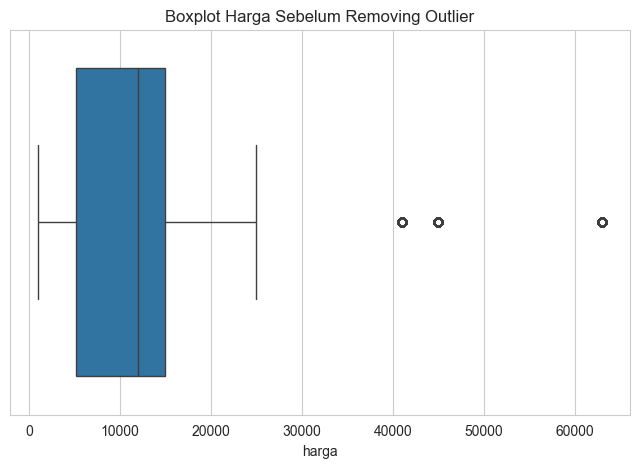

In [80]:
plt.figure(figsize=(8,5))
sns.boxplot(x=merged_df['harga'])
plt.title('Boxplot Harga Sebelum Removing Outlier')
plt.show()

In [81]:
Q1 = merged_df['harga'].quantile(0.25)
Q3 = merged_df['harga'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Batas bawah :', lower_bound)
print('Batas atas  :', upper_bound)

clean_df = merged_df[
    (merged_df['harga'] >= lower_bound) &
    (merged_df['harga'] <= upper_bound)
]

print('Jumlah data sebelum removing outlier :', merged_df.shape[0])
print('Jumlah data sesudah removing outlier :', clean_df.shape[0])

Batas bawah : -9500.0
Batas atas  : 29700.0
Jumlah data sebelum removing outlier : 23849
Jumlah data sesudah removing outlier : 21349


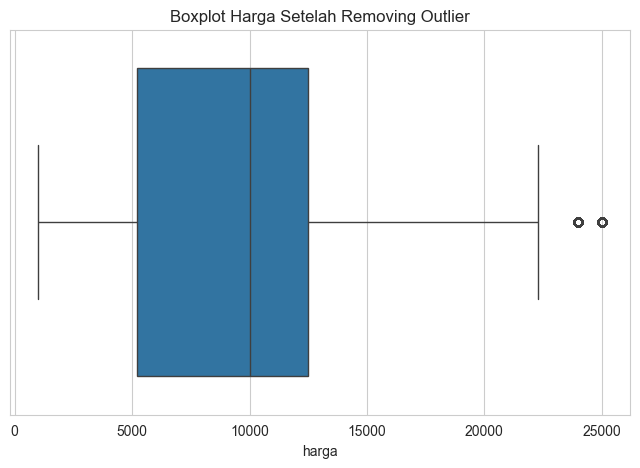

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x=clean_df['harga'])
plt.title('Boxplot Harga Setelah Removing Outlier')
plt.show()

# Removing outlier dilakukan menggunakan metode Interquartile Range (IQR).
# Data yang berada di luar batas bawah dan batas atas dianggap sebagai outlier dan dihapus dari dataset.

In [83]:
missing_values = merged_df.isnull().sum()

In [84]:
print('Total Missing Value :')
print(merged_df.isnull().sum().sum())

Total Missing Value :
398


In [85]:
jumlah_duplikat = merged_df.duplicated().sum()
print('Jumlah data duplikat :', jumlah_duplikat)

Jumlah data duplikat : 7502


In [86]:
dedup_df = merged_df.drop_duplicates()

print('Jumlah data sebelum deduplikasi :', merged_df.shape[0])
print('Jumlah data sesudah deduplikasi :', dedup_df.shape[0])

Jumlah data sebelum deduplikasi : 23849
Jumlah data sesudah deduplikasi : 16347


In [87]:
clean_df['tanggal'] = pd.to_datetime(
    clean_df['tanggal'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15008\4016570126.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['tanggal'] = pd.to_datetime(


In [88]:
produk_df = clean_df[
    clean_df['nama'] == 'Minyak Goreng 1 Lt'
]

In [89]:
produk_df['bulan'] = produk_df['tanggal'].dt.month


C:\Users\Administrator\AppData\Local\Temp\ipykernel_15008\1670673610.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  produk_df['bulan'] = produk_df['tanggal'].dt.month


In [90]:
penjualan_bulanan = produk_df.groupby('bulan')['jumlah'].sum()

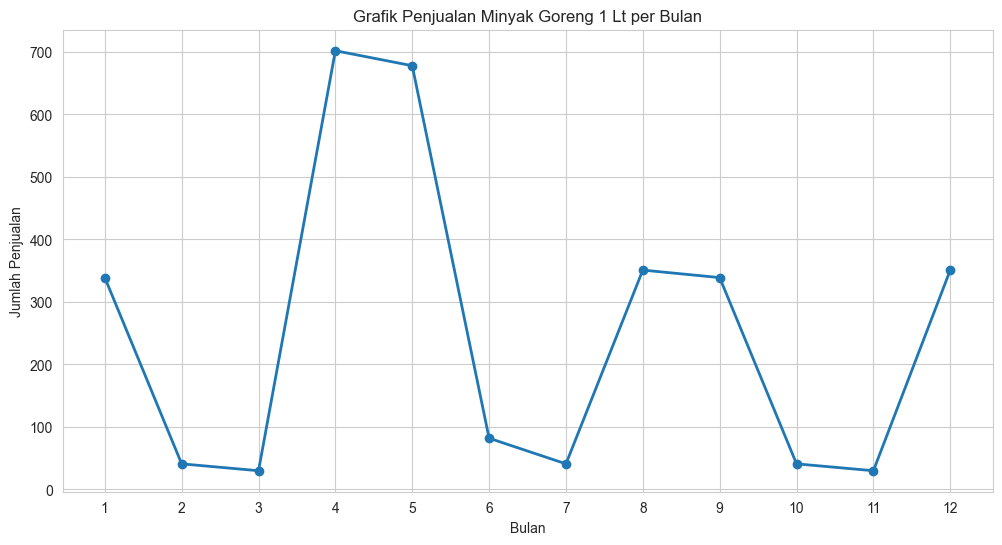

In [91]:
plt.figure(figsize=(12,6))

plt.plot(
    penjualan_bulanan.index,
    penjualan_bulanan.values,
    marker='o',
    linewidth=2
)

plt.title('Grafik Penjualan Minyak Goreng 1 Lt per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penjualan')
plt.xticks(range(1,13))
plt.grid(True)

plt.show()

# Kesimpulan
1. Dataset transaksi dari area MGL dan YK berhasil digabungkan menggunakan fungsi concat() sehingga menghasilkan total 23.849 baris data.
2. Proses removing outlier dilakukan pada kolom harga menggunakan metode IQR untuk menghapus nilai ekstrem.
3. Missing value dicek menggunakan fungsi isnull().sum() untuk mengetahui jumlah data kosong pada setiap kolom.
4. Data duplikat berhasil dideteksi menggunakan duplicated() dan dihapus menggunakan drop_duplicates().
5. Visualisasi line chart menunjukkan pola penjualan produk “Minyak Goreng 1 Lt” dari bulan 1 sampai bulan 12 berdasarkan total transaksi penjualan setiap bulan.